# Tesla Deliveries Prediction Using Machine Learning Pipeline

## Objective
The objective of this project is to build an end-to-end Machine Learning Pipeline to predict Tesla vehicle deliveries using historical production, pricing, battery, and regional data.

The project demonstrates:
- Data Preprocessing
- Feature Engineering
- Categorical Encoding
- Feature Scaling
- Linear Regression Modeling
- Model Evaluation
- Pipeline Implementation

## Import Required Libraries

In this step, all the necessary libraries for data manipulation, visualization, preprocessing, model building, and evaluation are imported.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.pipeline import Pipeline

## Load Dataset

The Tesla deliveries dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [2]:
data = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

## Exploratory Data Analysis (EDA)

EDA helps in understanding:

- Dataset structure
- Data types
- Missing values
- Statistical summary
- Feature distributions

This step ensures data quality before model training.

In [3]:
data.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
data.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
data.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [7]:
data.duplicated().sum()

np.int64(0)

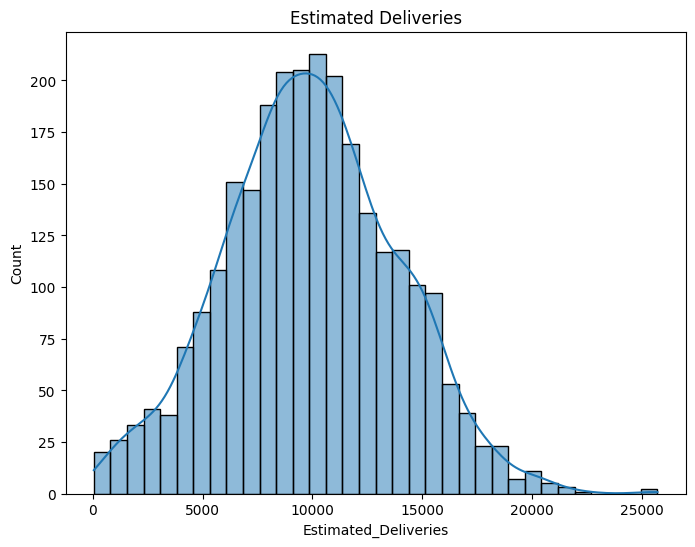

In [8]:
plt.figure(figsize=(8,6))
sns.histplot(data['Estimated_Deliveries'],kde=True)
plt.title('Estimated Deliveries')
plt.show()

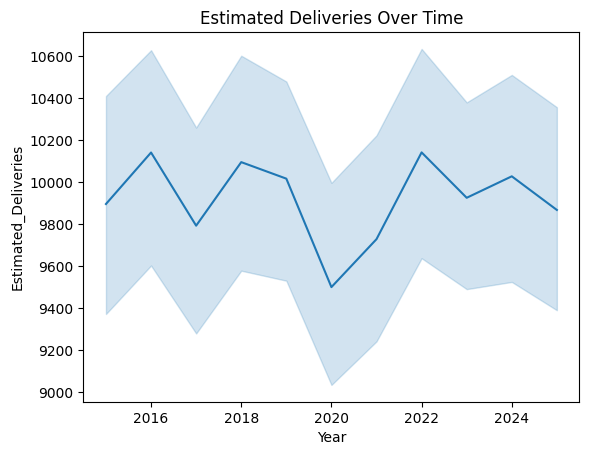

In [9]:
sns.lineplot(x='Year',y='Estimated_Deliveries',data=data)
plt.title('Estimated Deliveries Over Time')
plt.show()

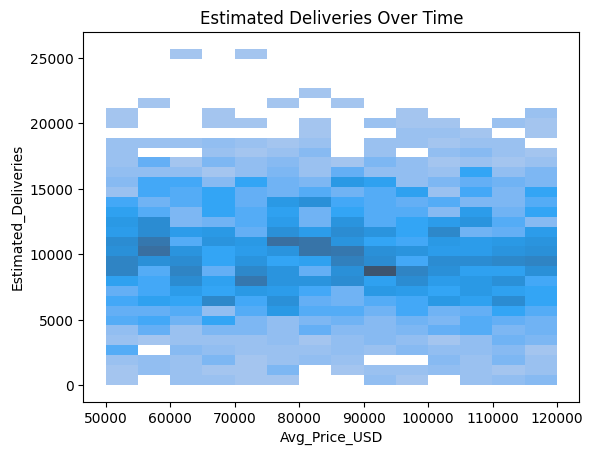

In [10]:
sns.histplot(x='Avg_Price_USD',y='Estimated_Deliveries',data=data)
plt.title('Estimated Deliveries Over Time')
plt.show()

## Feature and Target Selection

The target variable selected for prediction is:

**Estimated_Deliveries**

All remaining columns are used as predictor variables.

In [11]:
y = data['Estimated_Deliveries']
x = data.drop('Estimated_Deliveries',axis=1)

## Identify Feature Types

Features are categorized into:

### Numerical Features
- Year
- Month
- Production_Units
- Avg_Price_USD
- Battery_Capacity_kWh
- Range_km
- CO2_Saved_tons
- Charging_Stations

### Categorical Features
- Region
- Model
- Source_Type

Different preprocessing techniques are applied to each type.

In [12]:
numerical_cols = x.select_dtypes(include=np.number).columns
categorical_cols = x.select_dtypes(include='object').columns

## Data Preprocessing

Data preprocessing includes:

### Numerical Features
- Standard Scaling

### Categorical Features
- One-Hot Encoding

A ColumnTransformer is used to apply transformations efficiently.

In [19]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [20]:
model = LinearRegression()

## Machine Learning Pipeline

A Pipeline is created to combine:

1. Data Preprocessing
2. Linear Regression Model

Benefits of Pipeline:

- Prevents Data Leakage
- Improves Reproducibility
- Simplifies Workflow
- Enables End-to-End Automation

In [21]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

## Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

This helps evaluate model performance on unseen data.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                ('model', LinearRegression())])

In [24]:
y_pred = pipeline.predict(X_test)

In [25]:
result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(result)

      Actual     Predicted
2005    6991   7571.600001
32      9326   9433.894739
962     9061   8799.017879
1461    8951   9366.321985
478     8707   8922.602152
...      ...           ...
2033   18572  19123.109199
279     1761   1965.343810
2443   10136  10707.193283
2356   17905  18265.209067
1793   10489  10097.688523

[528 rows x 2 columns]


In [33]:
r2 = r2_score(y_test, y_pred)
print('R-squared:', r2)

R-squared: 0.990106298761102


## Model Persistence

The trained pipeline is saved using Joblib.

Benefits:

- Reusability
- Deployment Readiness
- Faster Predictions Without Retraining

In [42]:
import joblib

In [43]:
joblib.dump(pipeline, 'tesla_delivery_prediction_model.pkl')

['tesla_delivery_prediction_model.pkl']

In [44]:
loaded_model = joblib.load('tesla_delivery_prediction_model.pkl')

In [45]:
sample_data = x.loc[[0]]

In [46]:
predct = loaded_model.predict(sample_data)

In [47]:
print(predct[0])

17271.75690929444


# Conclusion

An end-to-end Machine Learning Pipeline was successfully implemented to predict Tesla deliveries.

Key achievements:

- Data preprocessing automated using Pipeline.
- Numerical features scaled using StandardScaler.
- Categorical features encoded using OneHotEncoder.
- Linear Regression model trained and evaluated.
- Model achieved a high R² score, indicating strong predictive capability.
- Pipeline saved for future deployment and inference.

This project demonstrates a complete machine learning workflow from data preprocessing to model deployment readiness.